In [1]:
import json
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

import numpy as np
import pandas as pd

In [4]:
def build_put_effort_dataframe(
    actions_path: str | Path,
    observations_path: str | Path,
    seed: int | None = None,
    reward_scheme: str | None = None,
) -> pd.DataFrame:

    rows = []
    skipped = 0

    with open(actions_path, "r", encoding="utf-8") as f_act, open(observations_path, "r", encoding="utf-8") as f_obs:
        for step, (act_line, obs_line) in enumerate(zip(f_act, f_obs)):
            act = json.loads(act_line)
            obs = json.loads(obs_line)

            # skip broken / terminal / empty rows
            if obs is None or act is None:
                skipped += 1
                continue

            if "agent_0" not in obs or "agent_0" not in act:
                skipped += 1
                continue

            if obs["agent_0"] is None or act["agent_0"] is None:
                skipped += 1
                continue

            if "observation" not in obs["agent_0"] or "action_mask" not in obs["agent_0"]:
                skipped += 1
                continue

            if "put_effort" not in act["agent_0"]:
                skipped += 1
                continue

            agent_obs = obs["agent_0"]["observation"]
            action_mask = obs["agent_0"]["action_mask"]

            running_projects = agent_obs["running_projects"]
            put_effort_action = act["agent_0"]["put_effort"]

            # projects are stored in agent_active_projects in the env
            # but in observation they are keys in running_projects dict
            # the action put_effort is 0 (no project) or 1..max_active (project 1..n)
            # we need to match the order. In the env, selected_project = action["put_effort"] - 1
            # refers to the index in self.agent_active_projects[idx]
            
            # Since the observation running_projects is a dict "project_{p_idx}", 
            # and the order depends on how it was built. 
            # In _get_running_projects_obs, it iterates over self._get_active_projects(agent_idx).
            
            active_project_keys = list(running_projects.keys())
            
            for i, proj_key in enumerate(active_project_keys):
                proj_data = running_projects[proj_key]
                
                rows.append({
                    "seed": seed,
                    "reward_scheme": reward_scheme,
                    "step": step,
                    "project_idx": i,
                    "put_effort": 1 if put_effort_action == (i + 1) else 0,
                    "required_effort": proj_data["required_effort"][0],
                    "prestige": proj_data["prestige"][0],
                    "novelty": proj_data["novelty"][0],
                    "time_left": proj_data["time_left"][0],
                    "peer_fit": proj_data["peer_fit"].mean() if isinstance(proj_data["peer_fit"], np.ndarray) else np.mean(proj_data["peer_fit"]),
                    "current_effort": proj_data["current_effort"][0],
                    "action_mask": action_mask["put_effort"][i+1],
                })

    if skipped > 0:
        print(f"[INFO] Seed {seed}: skipped {skipped} invalid rows")

    return pd.DataFrame(rows)

def build_put_effort_dataframe_for_seeds(
    log_dir: str | Path,
    reward_scheme: str,
    seeds: list[int],
) -> pd.DataFrame:
    """
    Build one combined put_effort dataframe over multiple seeds.
    Expected filenames:
    rl_ppo_{reward_scheme}_s{seed}_actions.jsonl
    rl_ppo_{reward_scheme}_s{seed}_observations.jsonl
    """

    log_dir = Path(log_dir)
    dfs = []
    print(seeds)

    for seed in seeds:
        actions_path = log_dir / f"rl_ppo_{reward_scheme}_s{seed}_actions.jsonl"
        observations_path = log_dir / f"rl_ppo_{reward_scheme}_s{seed}_observations.jsonl"

        if not actions_path.exists() or not observations_path.exists():
            print(f"[WARN] Missing files for seed {seed}: {actions_path.name} / {observations_path.name}")
            continue

        df_seed = build_put_effort_dataframe(
            actions_path=actions_path,
            observations_path=observations_path,
            seed=seed,
            reward_scheme=reward_scheme,
        )

        dfs.append(df_seed)

    if not dfs:
        return pd.DataFrame()

    return pd.concat(dfs, ignore_index=True)

In [5]:
seeds = list(range(101, 111))

effort_df = build_put_effort_dataframe_for_seeds(
    log_dir="../log",
    reward_scheme="by_effort",
    seeds=seeds,
)

[101, 102, 103, 104, 105, 106, 107, 108, 109, 110]
[INFO] Seed 102: skipped 580 invalid rows
[INFO] Seed 103: skipped 45 invalid rows
[INFO] Seed 104: skipped 534 invalid rows
[INFO] Seed 105: skipped 530 invalid rows
[INFO] Seed 107: skipped 23 invalid rows
[INFO] Seed 108: skipped 165 invalid rows
[INFO] Seed 109: skipped 541 invalid rows
[INFO] Seed 110: skipped 97 invalid rows


In [6]:
effort_df

,seed,reward_scheme,step,project_idx,put_effort,required_effort,prestige,novelty,time_left,peer_fit,current_effort,action_mask
0,101,by_effort,3,0,0,28,0.594894,0.254707,53,0.012500,0.000000,1
1,101,by_effort,4,0,1,28,0.594894,0.254707,52,0.012500,0.500000,1
2,101,by_effort,5,0,1,28,0.594894,0.254707,51,0.012500,1.000000,1
3,101,by_effort,5,1,0,12,0.232656,0.208934,20,0.012500,0.000000,1
4,101,by_effort,6,0,1,28,0.594894,0.254707,50,0.012500,1.500000,1
...,...,...,...,...,...,...,...,...,...,...,...,...
20308,110,by_effort,500,1,0,36,0.660167,0.366497,22,0.022404,0.000000,0
20309,110,by_effort,501,0,0,28,0.537531,0.213078,43,0.025572,0.447022,1
20310,110,by_effort,501,1,0,36,0.660167,0.366497,21,0.022404,0.000000,0
20311,110,by_effort,502,0,1,28,0.537531,0.213078,42,0.025572,0.894044,1


In [7]:
def build_step_summary(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate project-level dataframe to step-level statistics.
    One row = one seed-step.
    """

    group_cols = ["seed", "step"] if "seed" in df.columns else ["step"]
    # only rows where a project was selectable
    grouped = df[df["action_mask"] == 1].groupby(group_cols)

    summary = grouped.apply(lambda g: pd.Series({
        "n_running_projects": len(g),
        "any_effort_put": 1 if g["put_effort"].sum() > 0 else 0,

        "mean_selected_prestige": g[g["put_effort"] == 1]["prestige"].mean(),
        "mean_unselected_prestige": g[g["put_effort"] == 0]["prestige"].mean(),

        "mean_selected_novelty": g[g["put_effort"] == 1]["novelty"].mean(),
        "mean_unselected_novelty": g[g["put_effort"] == 0]["novelty"].mean(),

        "mean_selected_effort_req": g[g["put_effort"] == 1]["required_effort"].mean(),
        "mean_unselected_effort_req": g[g["put_effort"] == 0]["required_effort"].mean(),
        
        "mean_selected_peer_fit": g[g["put_effort"] == 1]["peer_fit"].mean(),
        "mean_unselected_peer_fit": g[g["put_effort"] == 0]["peer_fit"].mean(),
    }))

    return summary.reset_index()

In [8]:
summary = build_step_summary(effort_df)

In [9]:
summary.describe()

,seed,step,n_running_projects,any_effort_put,mean_selected_prestige,mean_unselected_prestige,mean_selected_novelty,mean_unselected_novelty,mean_selected_effort_req,mean_unselected_effort_req,mean_selected_peer_fit,mean_unselected_peer_fit
count,3445.000000,3445.000000,3445.00000,3445.000000,2931.000000,3373.000000,2931.000000,3373.000000,2931.000000,3373.000000,2931.000000,3373.000000
mean,105.608708,261.411901,5.17881,0.850798,0.521721,0.513961,0.233258,0.224982,24.791880,24.725321,0.024927,0.024794
std,2.980996,167.829673,2.09431,0.356339,0.158353,0.083600,0.059372,0.034636,7.950423,4.933439,0.010749,0.006588
min,101.000000,0.000000,1.00000,0.000000,0.115194,0.188627,0.110850,0.118835,4.000000,7.000000,0.012500,0.012500
25%,103.000000,110.000000,4.00000,1.000000,0.414498,0.465849,0.191039,0.203670,19.000000,21.500000,0.018875,0.020673
50%,106.000000,256.000000,5.00000,1.000000,0.505399,0.513749,0.227924,0.222719,25.000000,24.714286,0.022522,0.024262
75%,108.000000,400.000000,7.00000,1.000000,0.624560,0.561774,0.268701,0.242142,31.000000,28.000000,0.025000,0.028152
max,110.000000,599.000000,8.00000,1.000000,0.963302,0.949674,0.482534,0.375872,49.000000,49.000000,0.071372,0.062668


## Vergleich der Durchschnittswerte von Projekten mit vs. ohne Aufwand:
- Prestige: Investiert der Agent mehr in prestigeträchtige Projekte?
- Neuheit: Investiert der Agent mehr in neue Projekte?
- Aufwand: Bevorzugt der Agent Projekte mit weniger verbleibendem Aufwand?
- Peer Fit: Bevorzugt der Agent Projekte mit besserem Peer Fit?

In [10]:
summary[[
    "mean_selected_prestige",
    "mean_unselected_prestige",
    "mean_selected_novelty",
    "mean_unselected_novelty",
    "mean_selected_effort_req",
    "mean_unselected_effort_req",
    "mean_selected_peer_fit",
    "mean_unselected_peer_fit",
]].mean()

mean_selected_prestige         0.521721
mean_unselected_prestige       0.513961
mean_selected_novelty          0.233258
mean_unselected_novelty        0.224982
mean_selected_effort_req      24.791880
mean_unselected_effort_req    24.725321
mean_selected_peer_fit         0.024927
mean_unselected_peer_fit       0.024794
dtype: float64

## Logistische Regression: Können wir die Aufwandsverteilung basierend auf den Beobachtungen vorhersagen?


In [11]:
# Logistic Regression: Can we predict the effort allocation based on observations?
feature_cols = [
    "required_effort",
    "prestige",
    "novelty",
    "time_left",
    "peer_fit",
    "current_effort",
]

features = effort_df[feature_cols]
target = effort_df["put_effort"]

model = LogisticRegression(max_iter=1000)
model.fit(features, target)

print(dict(zip(feature_cols, model.coef_[0])))

{'required_effort': np.float64(-0.06646943321145271), 'prestige': np.float64(0.09651266596565293), 'novelty': np.float64(1.18997535042903), 'time_left': np.float64(0.04670784663498134), 'peer_fit': np.float64(-6.211445652997659), 'current_effort': np.float64(0.26200301667357884)}


## Koeffizienten

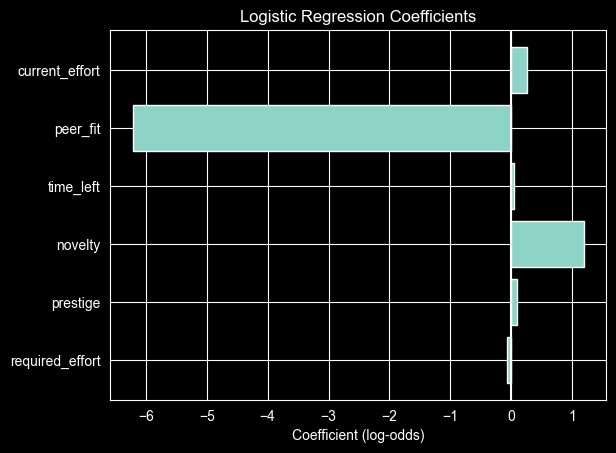

In [12]:
coefs = model.coef_[0]

plt.figure()
plt.barh(feature_cols, coefs)
plt.xlabel("Coefficient (log-odds)")
plt.title("Logistic Regression Coefficients")
plt.axvline(0)
plt.show()

## Probability vs Feature


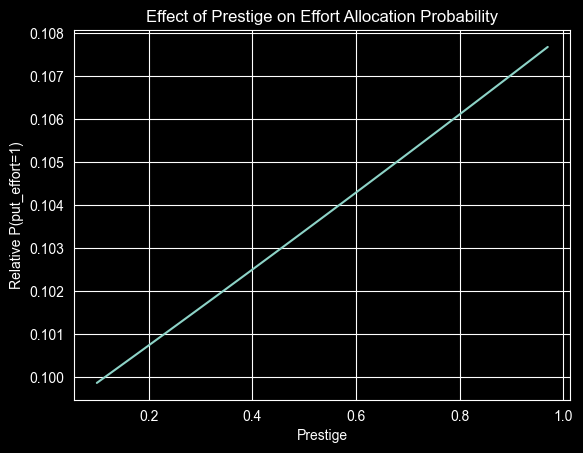

In [13]:
# Range für prestige
x_vals = np.linspace(
    effort_df["prestige"].min(),
    effort_df["prestige"].max(),
    100
)

# Mittelwerte der Features als Basis
mean_vals = features.mean().copy()

# Input DataFrame erzeugen (vectorized)
df_inputs = pd.DataFrame([mean_vals] * len(x_vals))
df_inputs["prestige"] = x_vals

# Wahrscheinlichkeiten berechnen
probs = model.predict_proba(df_inputs)[:, 1]

# Plot
plt.figure()
plt.plot(x_vals, probs)
plt.xlabel("Prestige")
plt.ylabel("Relative P(put_effort=1)")
plt.title("Effect of Prestige on Effort Allocation Probability")
# plt.ylim(0, 1)
plt.show()

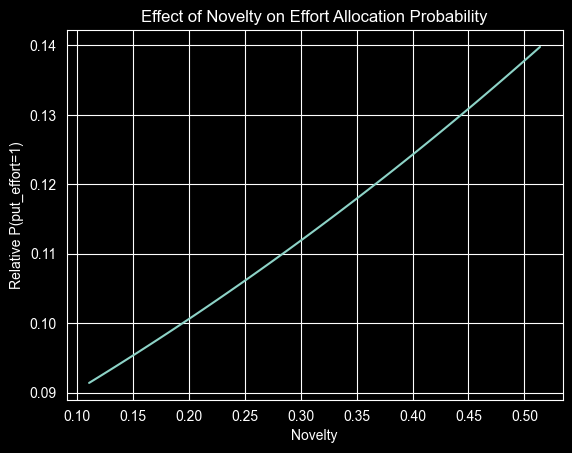

In [14]:
# Range für novelty
x_vals = np.linspace(
    effort_df["novelty"].min(),
    effort_df["novelty"].max(),
    100
)

# Mittelwerte der Features als Basis
mean_vals = features.mean().copy()

# Input DataFrame erzeugen (vectorized)
df_inputs = pd.DataFrame([mean_vals] * len(x_vals))
df_inputs["novelty"] = x_vals

# Wahrscheinlichkeiten berechnen
probs = model.predict_proba(df_inputs)[:, 1]

# Plot
plt.figure()
plt.plot(x_vals, probs)
plt.xlabel("Novelty")
plt.ylabel("Relative P(put_effort=1)")
plt.title("Effect of Novelty on Effort Allocation Probability")
plt.show()

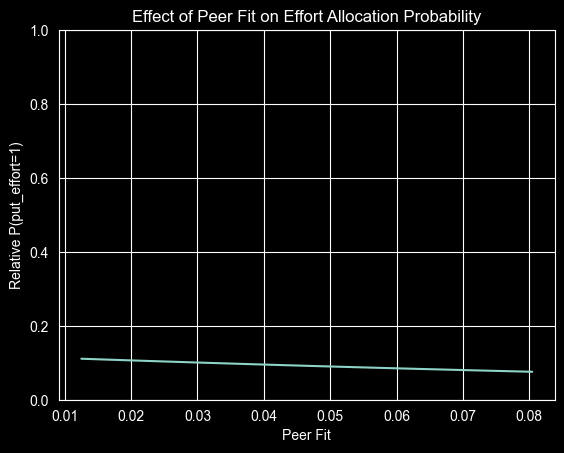

In [15]:
# Range für peer_fit
x_vals = np.linspace(
    effort_df["peer_fit"].min(),
    effort_df["peer_fit"].max(),
    100
)

# Mittelwerte der Features als Basis
mean_vals = features.mean().copy()

# Input DataFrame erzeugen (vectorized)
df_inputs = pd.DataFrame([mean_vals] * len(x_vals))
df_inputs["peer_fit"] = x_vals

# Wahrscheinlichkeiten berechnen
probs = model.predict_proba(df_inputs)[:, 1]

# Plot
plt.figure()
plt.plot(x_vals, probs)
plt.xlabel("Peer Fit")
plt.ylabel("Relative P(put_effort=1)")
plt.title("Effect of Peer Fit on Effort Allocation Probability")
plt.ylim(0, 1)
plt.show()

## Standardisierte Koeffizienten

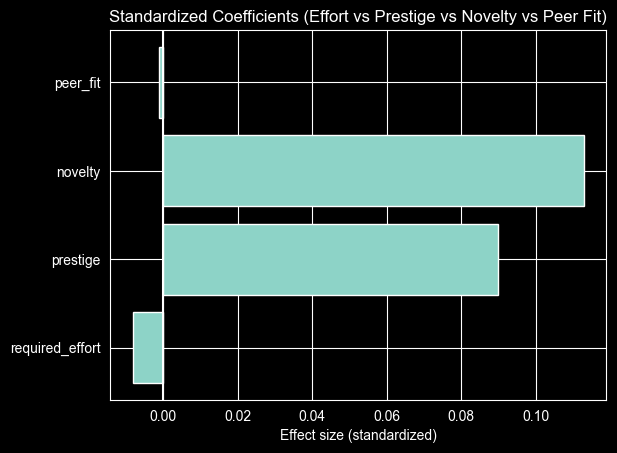

In [16]:
feature_cols = [
    "required_effort",
    "prestige",
    "novelty",
    "peer_fit",
]

features = effort_df[feature_cols]

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

model_scaled = LogisticRegression(max_iter=1000)
model_scaled.fit(features_scaled, target)

plt.figure()
plt.barh(feature_cols, model_scaled.coef_[0])
plt.title("Standardized Coefficients (Effort vs Prestige vs Novelty vs Peer Fit)")
plt.xlabel("Effect size (standardized)")
plt.axvline(0)
plt.show()

Effort, prestige, novelty and peer fit are expected to be the main drivers for effort allocation.

## Permutation importance: Wie stark beeinflusst jedes Feature die Vorhersage des Modells?


In [17]:
feature_cols = [
    "required_effort",
    "prestige",
    "novelty",
    "time_left",
    "peer_fit",
    "current_effort",
]
features = effort_df[feature_cols]

# Permutation importance
result = permutation_importance(model, features, target, n_repeats=10)

for i, col in enumerate(features.columns):
    print(col, result.importances_mean[i])

required_effort 0.002648550189533816
prestige 0.00029045438881507567
novelty 0.00031506916752819245
time_left 0.005282331511839711
peer_fit 0.0009107468123861762
current_effort 0.08217890021168708


In [18]:
# Counterfactual: What if we swap the peer_fit values?
feature_cols = [
    "required_effort",
    "prestige",
    "novelty",
    "time_left",
    "peer_fit",
    "current_effort",
]

features = effort_df[feature_cols]
target = effort_df["put_effort"]

model = LogisticRegression(max_iter=1000)
model.fit(features, target)

df_test = effort_df.copy()
df_test["peer_fit"] = np.random.permutation(df_test["peer_fit"].values)

orig_prob = model.predict_proba(effort_df[feature_cols])[:, 1]
new_prob = model.predict_proba(df_test[feature_cols])[:, 1]

change = np.abs(orig_prob - new_prob).mean()
print("Avg prob change (Peer Fit swap):", change)

Avg prob change (Peer Fit swap): 0.006236986203582734


In [19]:
feature_cols = [
    "required_effort",
    "prestige",
    "novelty",
    "time_left",
    "peer_fit",
    "current_effort",
]

features = effort_df[feature_cols]
target = effort_df["put_effort"]

model = LogisticRegression(max_iter=1000)
model.fit(features, target)

for col in feature_cols:
    df_test = effort_df.copy()
    df_test[col] = np.random.permutation(df_test[col].values)

    orig_prob = model.predict_proba(effort_df[feature_cols])[:, 1]
    new_prob = model.predict_proba(df_test[feature_cols])[:, 1]

    change = np.abs(orig_prob - new_prob).mean()
    print(col, change)

required_effort 0.05497371708877944
prestige 0.001491952701706825
novelty 0.00727482556689911
time_left 0.0639425736609177
peer_fit 0.006142396744426229
current_effort 0.1477858010642795
